# 04 | Weather becomes a climate question
**40 minutes · NetCDF, units, time and comparison periods**

**By the end:** inspect a climate data cube; convert kelvin to Celsius; compare a baseline with a recent period; count threshold days while retaining missingness.

**Case question:** Is a hot year the same as a change in climate?
Our 1991–2024 temperatures are **generated teaching data**, not Houston observations, reanalysis, or projections. A trend was deliberately built into them. They cannot demonstrate real climate change.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Works when Jupyter starts in the project root or a subfolder.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data/assets.csv').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Keep the notebooks and data folders together; open this project in Jupyter.')
DATA = ROOT / 'data'
OUT = ROOT / 'outputs'
OUT.mkdir(exist_ok=True)
plt.rcParams.update({'figure.figsize': (9, 5), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titleweight': 'bold', 'figure.dpi': 110})
print('Ready. Core lessons use bundled local data; no API key needed.')

Ready. Core lessons use bundled local data; no API key needed.


## 1. Know what kind of evidence you have
**Weather** describes conditions at a particular time. **Climate** describes their longer-term distribution: averages, seasonality, extremes and variability.

| Data type | What it is | Question to ask |
|---|---|---|
| Observation | Instrument measurement | Where is the instrument and how is it calibrated? |
| Reanalysis | Past conditions reconstructed using observations and a model | What are the grid scale and uncertainties? |
| Projection | Modelled future under specified assumptions | Which scenario, horizon, model and baseline? |
| Our synthetic data | Values created for this exercise | What did the generator deliberately build in? |

ERA5 is an example of reanalysis, not a future forecast. [Copernicus explains the distinction](https://climate.copernicus.eu/what-copernicus-climate-change-services-era5-reanalysis-dataset).

In [2]:
import xarray as xr
with xr.open_dataset(DATA / 'synthetic_daily_temperature.nc',engine='scipy') as source:
    climate = source.load()
display(climate)
print('Variable metadata:', climate.tasmax.attrs)
print('First date:', str(climate.time.values[0])[:10], '| Last:', str(climate.time.values[-1])[:10])

<xarray.Dataset> Size: 2MB
Dimensions:    (time: 12419, latitude: 6, longitude: 6)
Coordinates:
  * time       (time) datetime64[ns] 99kB 1991-01-01 1991-01-02 ... 2024-12-31
  * latitude   (latitude) float64 48B 29.88 29.82 29.77 29.73 29.68 29.62
  * longitude  (longitude) float64 48B -95.47 -95.42 -95.38 -95.32 -95.27 -95.22
Data variables:
    tasmax     (time, latitude, longitude) float32 2MB nan 289.8 ... 296.3 296.6
Attributes:
    title:           SYNTHETIC daily maximum air temperature for teaching
    source:          Seed 42; sinusoidal season + imposed 0.045 C/year trend ...
    geospatial_crs:  EPSG:4326
    Conventions:     CF-1.8

Variable metadata: {'units': 'K', 'long_name': 'Synthetic daily maximum near-surface air temperature', 'standard_name': 'air_temperature', 'cell_methods': 'time: maximum'}
First date: 1991-01-01 | Last: 2024-12-31


NetCDF stores named variables and dimensions. Here `tasmax` means daily maximum air temperature, measured in kelvin. The array dimensions are **time × latitude × longitude**.

Selecting one grid cell gives a time series. Selecting one date gives a map. We use one of the bundled cells, not a city-wide observation.

Selected cell center: 29.725 -95.32499999999999


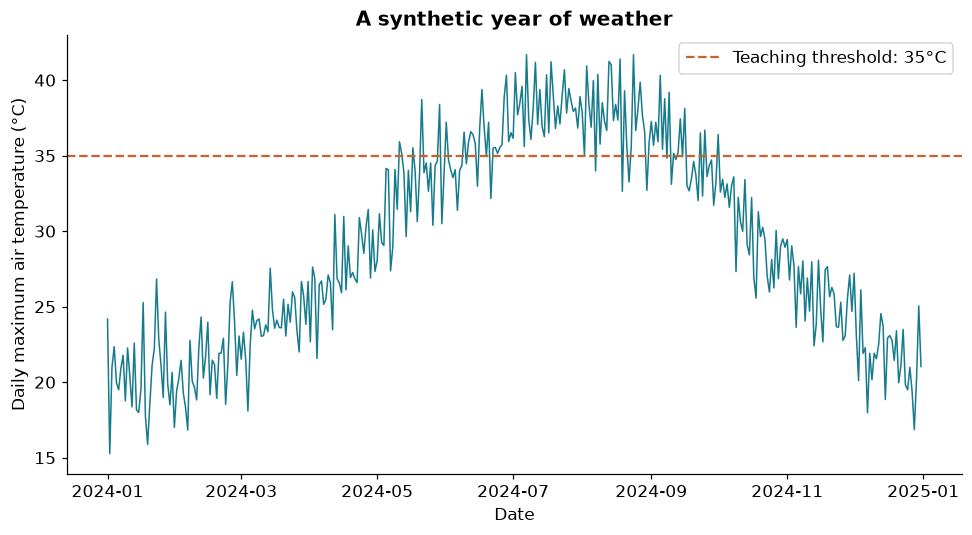

In [3]:
temperature_c = climate.tasmax - 273.15
temperature_c.attrs = {'units':'degC','long_name':'Synthetic daily maximum air temperature'}
series = temperature_c.sel(latitude=29.725,longitude=-95.325,method='nearest')
print('Selected cell center:',float(series.latitude),float(series.longitude))
recent = series.sel(time='2024')
fig, ax = plt.subplots()
ax.plot(recent.time.values,recent.values,color='#167b8d',linewidth=1)
ax.axhline(35,color='#c56433',linestyle='--',label='Teaching threshold: 35°C')
ax.set(title='A synthetic year of weather',xlabel='Date',ylabel='Daily maximum air temperature (°C)')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Compare like with like
We use 1991–2020 as a 30-year reference period and 2020–2024 as a recent five-year period. They overlap by one year, which we state explicitly. The five-year mean is **not** a new 30-year climate normal.
We compare monthly means with the same months to avoid mistaking seasonality for change. Here the quantity is the mean of daily maxima, not the all-hours mean temperature.

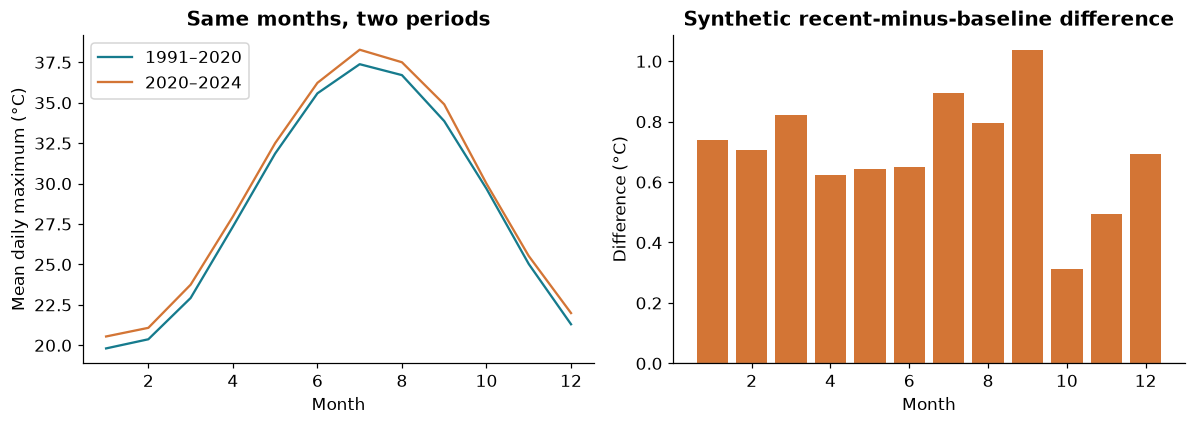

In [4]:
baseline = series.sel(time=slice('1991','2020')).groupby('time.month').mean()
recent_mean = series.sel(time=slice('2020','2024')).groupby('time.month').mean()
fig, axes = plt.subplots(1,2,figsize=(11,4))
axes[0].plot(baseline.month,baseline,label='1991–2020',color='#167b8d')
axes[0].plot(recent_mean.month,recent_mean,label='2020–2024',color='#d37535')
axes[0].set(title='Same months, two periods',xlabel='Month',ylabel='Mean daily maximum (°C)')
axes[0].legend()
anomaly = recent_mean - baseline
axes[1].bar(anomaly.month,anomaly,color='#d37535')
axes[1].axhline(0,color='gray',linewidth=0.8)
axes[1].set(title='Synthetic recent-minus-baseline difference',xlabel='Month',ylabel='Difference (°C)')
plt.tight_layout()
plt.show()

## 3. Count hot days without turning missing data into “cool” days
Comparing a missing number to 35 returns false. A naive sum can therefore report zero hot days for an entirely missing year. We require at least 90% of the year's daily values. This is an illustrative completeness rule, not a climate-data standard.
For partially missing accepted years, the result counts **observed available hot days**, not an imputed full-year total. Missingness can still bias it.

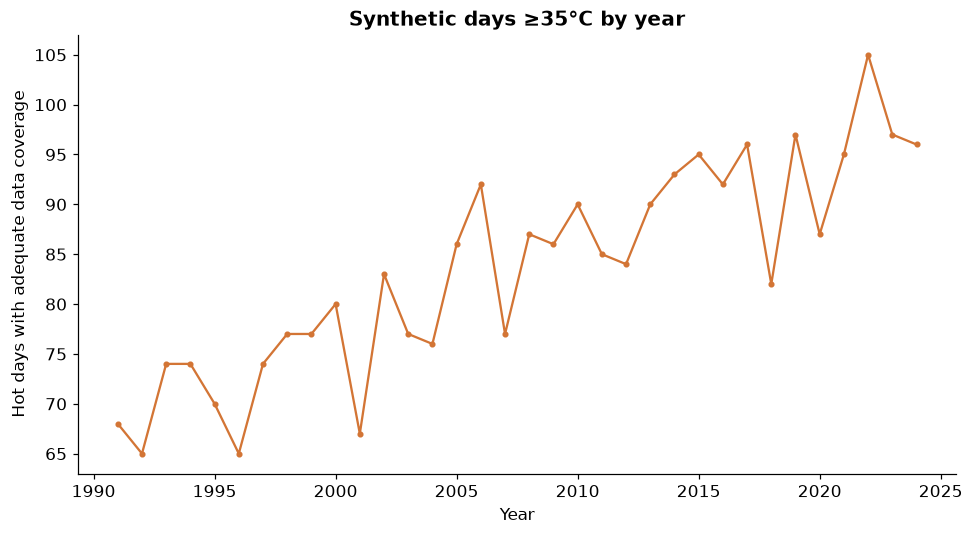

Entirely missing 2005: naive count = 0 ; coverage-aware result = nan


In [5]:
threshold_c = 35  # TRY: 32 or 38, then rerun this cell and inspect the chart.
def annual_hot_days(temperatures, threshold):
    valid_days = temperatures.resample(time='YS').count()
    # Actual number of calendar days, including leap years.
    calendar_days = xr.ones_like(temperatures).resample(time='YS').sum()
    observed_hot = (temperatures >= threshold).resample(time='YS').sum()
    return observed_hot.where(valid_days/calendar_days >= 0.9)

annual = annual_hot_days(series, threshold_c)
fig, ax = plt.subplots()
ax.plot(annual.time.dt.year,annual,marker='o',markersize=3,color='#d37535')
ax.set(title=f'Synthetic days ≥{threshold_c}°C by year',xlabel='Year',ylabel='Hot days with adequate data coverage')
plt.tight_layout()
plt.show()

# Inspect the deliberately missing year at a different cell.
gap_cell = temperature_c.isel(latitude=1,longitude=1)
naive = int((gap_cell.sel(time='2005') >= threshold_c).sum())
checked = float(annual_hot_days(gap_cell,threshold_c).sel(time='2005').item())
print('Entirely missing 2005: naive count =',naive,'; coverage-aware result =',checked)
assert np.isnan(checked)

## Try it · 5 minutes
1. Does raising the temperature threshold increase or decrease the number of hot days?
2. Explain why one hot year cannot by itself establish a climate trend.
3. Before using a future heat projection, name four pieces of metadata you would request.

**Coding extension:** change the recent period to 2021–2024 to remove the overlap, and compare monthly anomalies with the original result. Repeat hot-day counts at 32, 35 and 38°C. Explain how changes in the threshold and comparison period affect the interpretation.

**Takeaway:** the period, aggregation, units, scenario and missingness are part of the number's meaning.
Reference for the array operations: [xarray time-series guide](https://docs.xarray.dev/en/stable/user-guide/time-series.html).